In [1]:
import uproot, glob
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob, pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
import scipy
from scipy.stats import norm
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)

mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-7gwh9941 because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
out_dir='../analysis_run3/AN_Note_Plot/mass_regression_miniAOD_AOD'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
save = True

5_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy_HBHE_energy
keys dict_keys(['m_true', 'm_pred', 'mae', 'mre'])


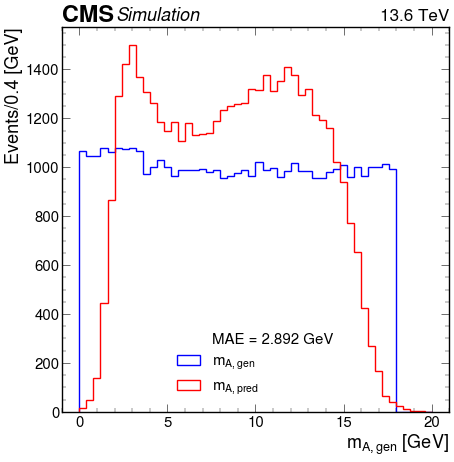

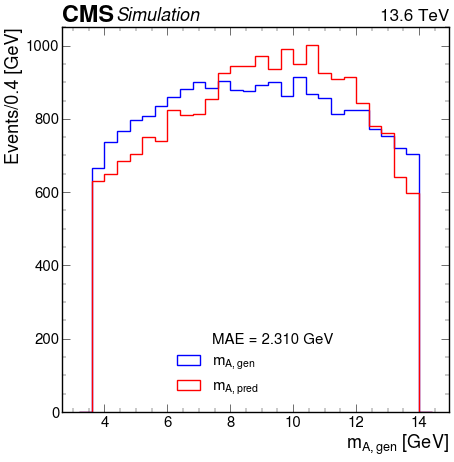

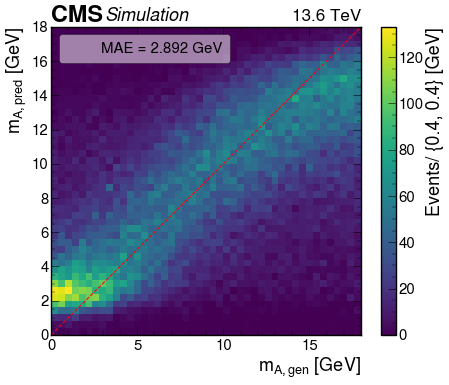

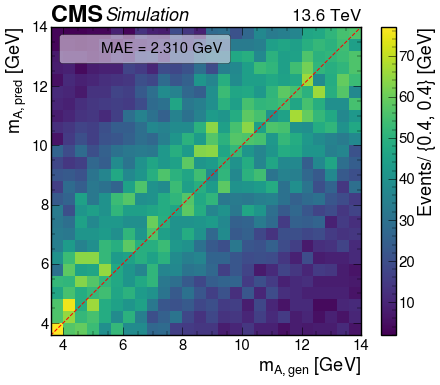

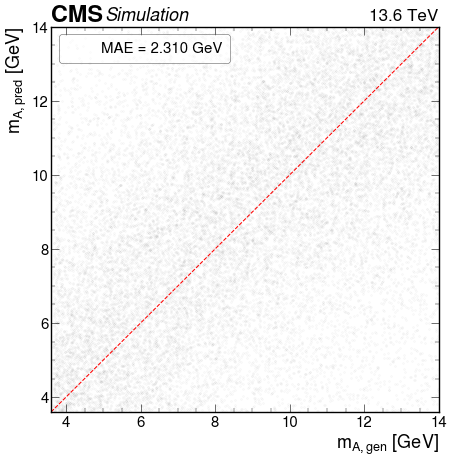

In [3]:
data_dir ='../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new'

a=1 # 0,1
b=1 # 0,1
ua_dir = ['ResNet_mapA_mass_reg_miniAOD', 'ResNet_mapA_mass_reg_AOD'][a]
model_dir = ['4_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy','5_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy_HBHE_energy'][b]
#[41, 41]
#[49, 45]
if a==0 and (b==0 or b==1):
    epoch = 41
if a==1 and b==0:
    epoch = 49
if a==1 and b==1:
    epoch = 45
data_file = glob.glob(f"{data_dir}/{ua_dir}/{model_dir}/INFERENCE_DATA/epoch{epoch}_*.pkl")[0]

print(model_dir)
# print(f"loaded data file ------>  {data_file}")
infile = open(f"{data_file}", "rb")
data = pickle.load(infile)
print("keys", data.keys())
# print(f"data.keys()------>  {data.keys()}")
infile.close()

m_true = data["m_true"]
m_pred = data["m_pred"]
# mask_real = m_true >= 3.6

# m_true = m_true[mask_real]
# m_pred = m_pred[mask_real]

mask1 = (m_true >= 3.6) & (m_true <=14)
m_true_ = m_true[mask1]
m_pred_ = m_pred[mask1]

mask2 = (m_pred_ >=3.6) & (m_pred_ <=14)
m_true__ = m_true_[mask2]
m_pred__ = m_pred_[mask2]



m0_min = 0
m0_max = 18.1
bin_size =0.4

dpi_ =50

fig, ax = plt.subplots(dpi=dpi_)
plt.plot([], [], ' ', label='MAE = %.3f GeV'%np.mean(np.abs(m_true - m_pred)))
plt.hist(m_true,  bins=np.arange(m0_min,m0_max+2,bin_size), histtype='step', label=r'$m_{A, gen}$', linestyle='-', color='blue', linewidth=2)
plt.hist(m_pred, bins=np.arange(m0_min,m0_max+2,bin_size), histtype='step', label=r'$m_{A, pred}$', linestyle='-', color='red', linewidth=2)
# plt.hist(m0, bins=np.arange(m0_min,m0_max+10,bin_size), histtype='step', label=r'$jet_{mass}$', linestyle='-', color='black')
plt.xlabel(r'$m_{A, gen}$ [GeV]')
plt.ylabel(r'Events/0.4 [GeV]')
plt.legend(loc='best')

hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.legend(loc='best', frameon=False, framealpha=0.5, facecolor='white', edgecolor='black')
# plt.savefig(f'{out_dir}/mtrue_mpred_all_{ua_dir}_{model_dir}_epoch_{epoch}_full_hist.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()

    
    
fig, ax = plt.subplots(dpi=dpi_)
plt.plot([], [], ' ', label='MAE = %.3f GeV'%np.mean(np.abs(m_true__ - m_pred__)))
plt.hist(m_true__,  bins=np.arange(3.2, 14.5,bin_size), histtype='step', label=r'$m_{A, gen}$', linestyle='-', color='blue', linewidth=2)
plt.hist(m_pred__, bins=np.arange(3.2, 14.5,bin_size), histtype='step', label=r'$m_{A, pred}$', linestyle='-', color='red', linewidth=2)
plt.xlabel(r'$m_{A, gen}$ [GeV]')
plt.ylabel(r'Events/0.4 [GeV]')
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/mtrue_mpred_roi_{ua_dir}_{model_dir}_epoch_{epoch}_hist.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
    

fig, ax = plt.subplots(figsize=(10,8),dpi=dpi_)
plt.plot([], [], ' ', label='MAE = %.3f GeV'%np.mean(np.abs(m_true - m_pred)))
hist = plt.hist2d(np.squeeze(m_true), np.squeeze(m_pred), bins=[np.arange(m0_min, m0_max, .4), np.arange(m0_min, m0_max, .4)])
plt.xlabel(r'$m_{A, gen}$ [GeV]')
plt.ylabel(r'$m_{A, pred}$ [GeV]')
plt.plot((m0_min, m0_max), (m0_min, m0_max), color='r', linestyle='--')
plt.colorbar().set_label(label='Events/ {0.4, 0.4} [GeV]')
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.legend(loc='upper left', frameon=True, framealpha=0.5, facecolor='white', edgecolor='black')
# plt.savefig(f'{out_dir}/mtrue_mpred_all_{ua_dir}_{model_dir}_epoch_{epoch}_full_2d_hist.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()

fig, ax = plt.subplots(figsize=(10,8),dpi=dpi_)
plt.plot([], [], ' ', label='MAE = %.3f GeV'%np.mean(np.abs(m_true__ - m_pred__)))
hist = plt.hist2d(np.squeeze(m_true__), np.squeeze(m_pred__), bins=[np.arange(3.6, 14.1, .4), np.arange(3.6, 14.1, .4)])
plt.xlabel(r'$m_{A, gen}$ [GeV]')
plt.ylabel(r'$m_{A, pred}$ [GeV]')
plt.plot((m0_min, m0_max), (m0_min, m0_max), color='r', linestyle='--')
plt.colorbar().set_label(label='Events/ {0.4, 0.4} [GeV]')
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.legend(loc='upper left', frameon=True, framealpha=0.5, facecolor='white', edgecolor='black')
# plt.savefig(f'{out_dir}/mtrue_mpred_roi_{ua_dir}_{model_dir}_epoch_{epoch}_2d_hist.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()


fig, ax = plt.subplots(dpi=dpi_)
plt.plot(m_true__, m_pred__, ".", color='black', alpha=0.02, label='MAE = %.3f GeV'%np.mean(np.abs(m_true__ - m_pred__)))
plt.xlabel(r'$m_{A, gen}$ [GeV]')
plt.ylabel(r'$m_{A, pred}$ [GeV]')
m0_min, m0_max = 3.6, 14.0
plt.plot((m0_min, m0_max), (m0_min, m0_max), color='r', linestyle='--')
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.xlim(m0_min, m0_max)
plt.ylim(m0_min, m0_max)
plt.legend(loc='upper left', frameon=True, framealpha=0.5, facecolor='white', edgecolor='black')
# plt.savefig(f'{out_dir}/mtrue_mpred_roi_scatter_{ua_dir}_{model_dir}_epoch_{epoch}.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()



In [52]:

in_dir = "../analysis_run3/Data_for_plots"

ResNet_miniAOD_4 ="ResNet_mapA_signal_backgrounds_4_ch_inference_miniAOD"
ResNet_miniAOD_5 ="ResNet_mapA_signal_backgrounds_5_ch_inference_miniAOD"
ResNet_AOD_4 ="ResNet_mapA_signal_backgrounds_4_ch_inference_AOD"
ResNet_AOD_5 ="ResNet_mapA_signal_backgrounds_5_ch_inference_AOD"

signals = [3.7, 4, 5, 6, 8, 10, 12, 14]

signal_files_miniAOD = [
    "IMG_signal_mass_3p7_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_4_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_5_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_6_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_8_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_10_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_12_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_14_GeV_miniAOD_combined.pkl",
]

signal_files_AOD = [
    "IMG_signal_mass_3p7_GeV_AOD_combined.pkl",
    "IMG_signal_mass_4_GeV_AOD_combined.pkl",
    "IMG_signal_mass_5_GeV_AOD_combined.pkl",
    "IMG_signal_mass_6_GeV_AOD_combined.pkl",
    "IMG_signal_mass_8_GeV_AOD_combined.pkl",
    "IMG_signal_mass_10_GeV_AOD_combined.pkl",
    "IMG_signal_mass_12_GeV_AOD_combined.pkl",
    "IMG_signal_mass_14_GeV_AOD_combined.pkl",
]


bacground = ["DYto2L", "HTo2Tau", "QCD", "TTbar", "Wjets"]
background_files_miniAOD = [
    "IMG_background_DYto2L_miniAOD_combined.pkl",
    "IMG_background_HTo2Tau_miniAOD_combined.pkl",
    "IMG_background_QCD_miniAOD_combined.pkl",
    "IMG_background_TTbar_miniAOD_combined.pkl",
    "IMG_background_Wjets_miniAOD_combined.pkl",
]

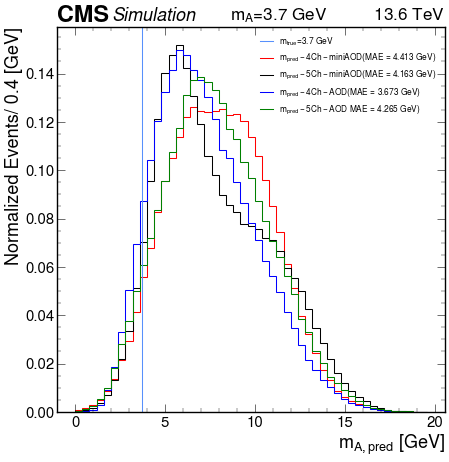

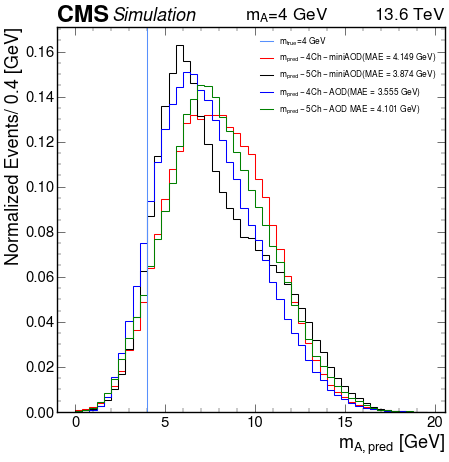

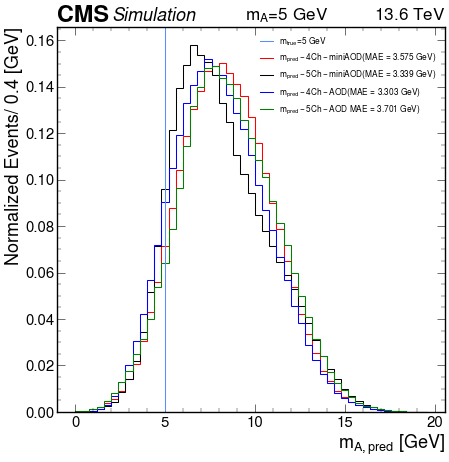

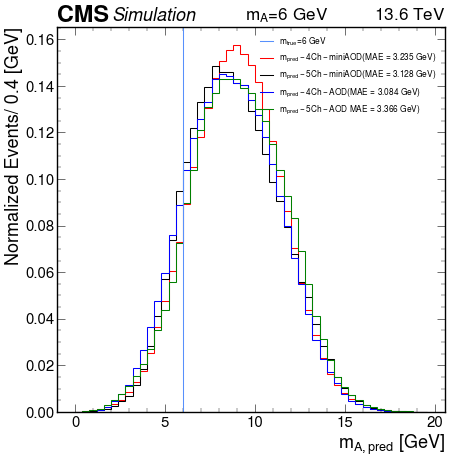

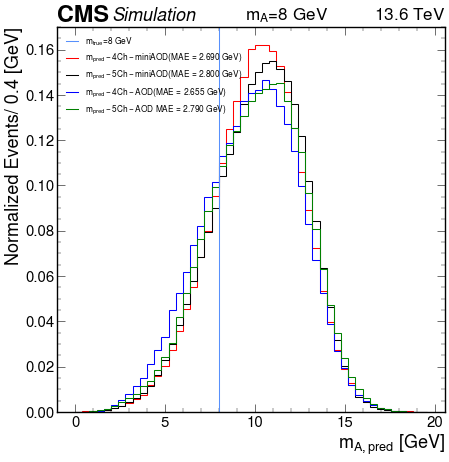

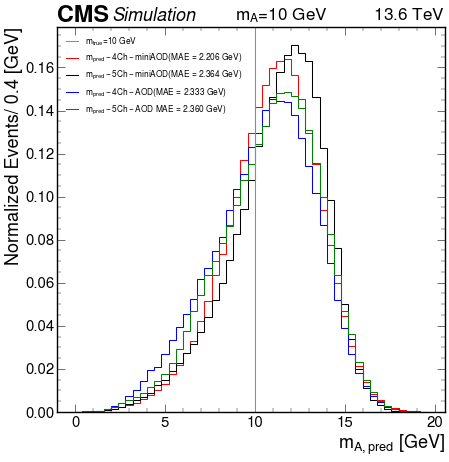

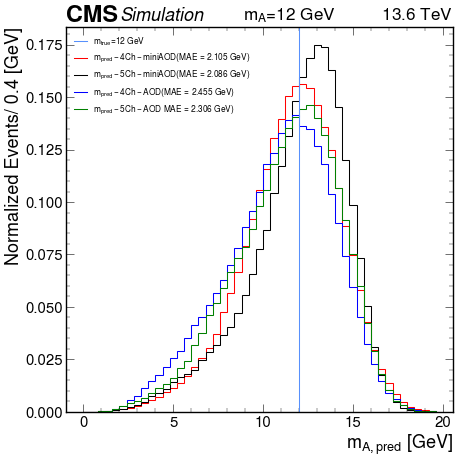

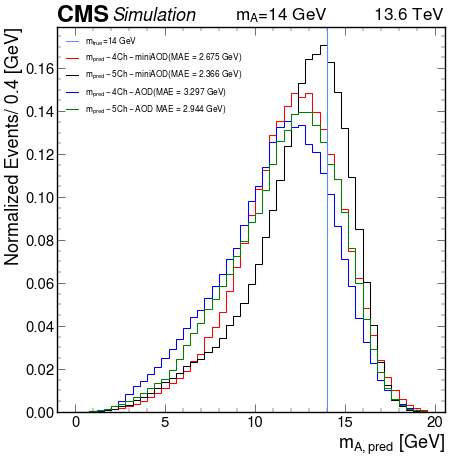

In [5]:
m0_min= 0
m0_max=20
bin_size =0.4
for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    
 
    data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
    infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
    data_miniAOD_4 = pickle.load(infile_miniAOD_4)
    infile_miniAOD_4.close()
    m_pred_miniAOD_4 = data_miniAOD_4["m_pred"]


    data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
    infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
    data_miniAOD_5 = pickle.load(infile_miniAOD_5)
    infile_miniAOD_5.close()
    m_pred_miniAOD_5 = data_miniAOD_5["m_pred"]

    data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
    infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
    data_AOD_4 = pickle.load(infile_AOD_4)
    infile_AOD_4.close()
    m_pred_AOD_4 = data_AOD_4["m_pred"]
    
    data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
    infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
    data_AOD_5 = pickle.load(infile_AOD_5)
    infile_AOD_5.close()
    m_pred_AOD_5 = data_AOD_5["m_pred"]

    dpi_ = 50
    
    fig, ax = plt.subplots(dpi=dpi_)
    plt.axvline(signals[i], label=r"$m_{true}$" + f"={signals[i]} GeV")
    h1=np.histogram(m_pred_miniAOD_4, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h1, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(signals[i] - m_pred_miniAOD_4)), color='red', density=True)
    h2=np.histogram(m_pred_miniAOD_5, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h2, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(signals[i] - m_pred_miniAOD_5)), linestyle='-', color='black', density=True)
    h3=np.histogram(m_pred_AOD_4, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h3, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-AOD$' + '(MAE = %.3f GeV)' %np.mean(np.abs(signals[i] - m_pred_AOD_4)), linestyle='-', color='blue', density=True)
    h4=np.histogram(m_pred_AOD_5, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h4, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-AOD$' + ' MAE = %.3f GeV)' %np.mean(np.abs(signals[i] - m_pred_AOD_5)), linestyle='-', color='green', density=True)
    plt.xlabel(r'$m_{A, pred}$ [GeV]')
    plt.ylabel('Normalized Events/ 0.4 [GeV]')
    plt.legend(loc='best', fontsize=12)
    hep.cms.label(llabel="Simulation", rlabel=f"$m_A$={signals[i]} GeV          "    +   "13.6 TeV", loc=0, ax=ax)
    signal_tag = f"{signals[i]}".replace('.', 'p')
    # plt.savefig(f'{out_dir}/signal_mass_{signal_tag}_inference_miniAOD_AOD_4_5_ch_comparision_epoch_{epoch}.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
    plt.show()

### Correction using mean of residuals from signal samples

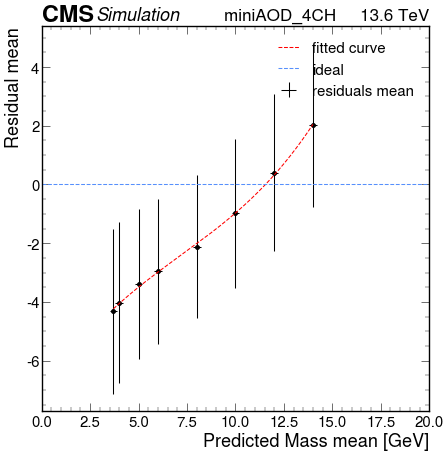

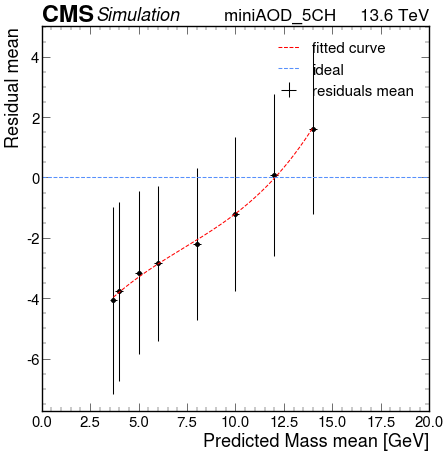

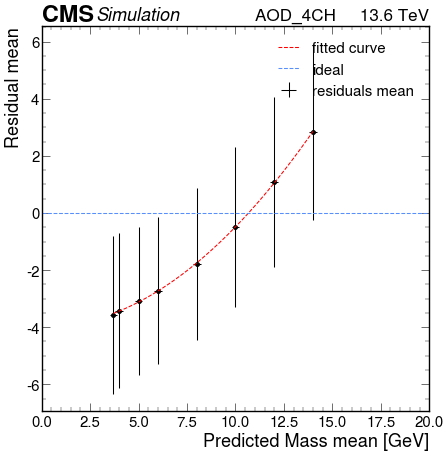

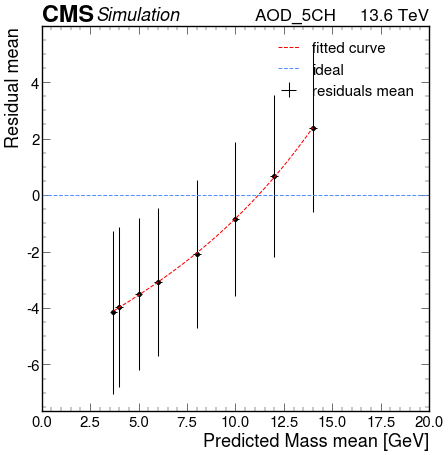

In [6]:
m0_min= 0
m0_max=20
bin_size =0.4
# signals = [3.7, 4, 5, 6, 8, 10]

residuals_mean_miniAOD_4 , residuals_std_miniAOD_4 = [], []
residuals_mean_miniAOD_5 , residuals_std_miniAOD_5 = [], []
residuals_mean_AOD_4 , residuals_std_AOD_4 = [], []
residuals_mean_AOD_5 , residuals_std_AOD_5 = [], []

for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    
    # if i >5: break 
        
    data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
    infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
    data_miniAOD_4 = pickle.load(infile_miniAOD_4)
    infile_miniAOD_4.close()
    m_pred_miniAOD_4 = data_miniAOD_4["m_pred"]
    residual_m_pred_miniAOD_4 = signals[i]- m_pred_miniAOD_4
    residuals_mean_miniAOD_4.append(np.mean(residual_m_pred_miniAOD_4))
    residuals_std_miniAOD_4.append(np.std(residual_m_pred_miniAOD_4))

    data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
    infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
    data_miniAOD_5 = pickle.load(infile_miniAOD_5)
    infile_miniAOD_5.close()
    m_pred_miniAOD_5 = data_miniAOD_5["m_pred"]
    residual_m_pred_miniAOD_5 = signals[i]- m_pred_miniAOD_5
    residuals_mean_miniAOD_5.append(np.mean(residual_m_pred_miniAOD_5))
    residuals_std_miniAOD_5.append(np.std(residual_m_pred_miniAOD_5))

    data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
    infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
    data_AOD_4 = pickle.load(infile_AOD_4)
    infile_AOD_4.close()
    m_pred_AOD_4 = data_AOD_4["m_pred"]
    residual_m_pred_AOD_4 = signals[i]- m_pred_AOD_4
    residuals_mean_AOD_4.append(np.mean(residual_m_pred_AOD_4))
    residuals_std_AOD_4.append(np.std(residual_m_pred_AOD_4))
    
    data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
    infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
    data_AOD_5 = pickle.load(infile_AOD_5)
    infile_AOD_5.close()
    m_pred_AOD_5 = data_AOD_5["m_pred"]
    residual_m_pred_AOD_5 = signals[i]- m_pred_AOD_5
    residuals_mean_AOD_5.append(np.mean(residual_m_pred_AOD_5))
    residuals_std_AOD_5.append(np.std(residual_m_pred_AOD_5))


    

degree_mean = 3
dpi_ = 50
fig, ax = plt.subplots(dpi=dpi_)   
coeff_mean_miniAOD_4 = np.polyfit(signals, residuals_mean_miniAOD_4, degree_mean)
polynomial_mean_miniAOD_4 = np.poly1d(coeff_mean_miniAOD_4)
x = np.linspace(min(signals),max(signals), num=1000)
y_fit_mean_miAOD_4 = polynomial_mean_miniAOD_4(x)
plt.scatter(signals, residuals_mean_miniAOD_4, color='black',marker='o')
plt.errorbar(signals, residuals_mean_miniAOD_4, xerr=0.2, yerr=residuals_std_miniAOD_4, fmt='none', color='black', label='residuals mean')
plt.plot(x,y_fit_mean_miAOD_4, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mean")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="miniAOD_4CH     13.6 TeV", loc=0, ax=ax)
plt.show() 



fig, ax = plt.subplots(dpi=dpi_)   
coeff_mean_miniAOD_5 = np.polyfit(signals, residuals_mean_miniAOD_5, degree_mean)
polynomial_mean_miniAOD_5 = np.poly1d(coeff_mean_miniAOD_5)
y_fit_mean_miniAOD_5 = polynomial_mean_miniAOD_5(x)
plt.scatter(signals, residuals_mean_miniAOD_5, color='black',marker='o')
plt.errorbar(signals, residuals_mean_miniAOD_5, xerr=0.2, yerr=residuals_std_miniAOD_5, fmt='none', color='black', label='residuals mean')
plt.plot(x,y_fit_mean_miniAOD_5, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mean")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="miniAOD_5CH     13.6 TeV", loc=0, ax=ax)
plt.show()

fig, ax = plt.subplots(dpi=dpi_)   
coeff_mean_AOD_4 = np.polyfit(signals, residuals_mean_AOD_4, degree_mean)
polynomial_mean_AOD_4 = np.poly1d(coeff_mean_AOD_4)
y_fit_mean_AOD_4 = polynomial_mean_AOD_4(x)
plt.scatter(signals, residuals_mean_AOD_4, color='black',marker='o')
plt.errorbar(signals, residuals_mean_AOD_4, xerr=0.2, yerr=residuals_std_AOD_4, fmt='none', color='black', label='residuals mean')
plt.plot(x,y_fit_mean_AOD_4, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mean")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="AOD_4CH     13.6 TeV", loc=0, ax=ax)
plt.show() 

fig, ax = plt.subplots(dpi=dpi_)   
coeff_mean_AOD_5 = np.polyfit(signals, residuals_mean_AOD_5, degree_mean)
polynomial_mean_AOD_5 = np.poly1d(coeff_mean_AOD_5)
y_fit_mean_AOD_5 = polynomial_mean_AOD_5(x)
plt.scatter(signals, residuals_mean_AOD_5, color='black',marker='o')
plt.errorbar(signals, residuals_mean_AOD_5, xerr=0.2, yerr=residuals_std_AOD_5, fmt='none', color='black', label='residuals mean')
plt.plot(x,y_fit_mean_AOD_5, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mean")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="AOD_5CH     13.6 TeV", loc=0, ax=ax)
plt.show() 

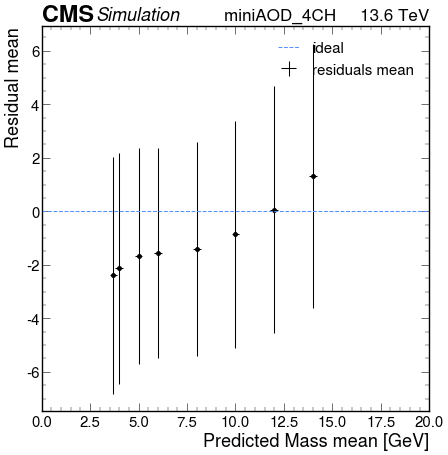

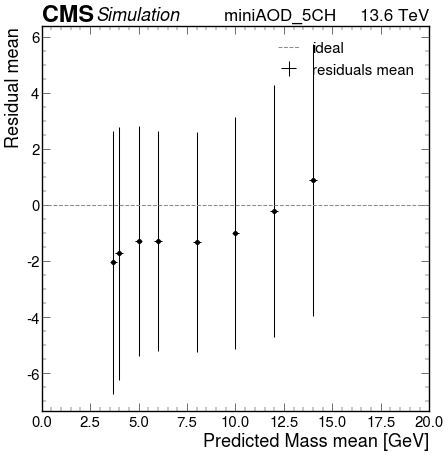

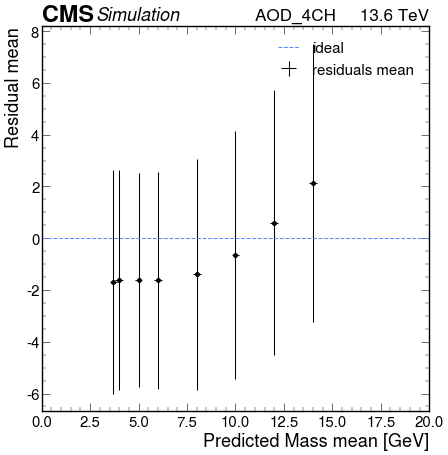

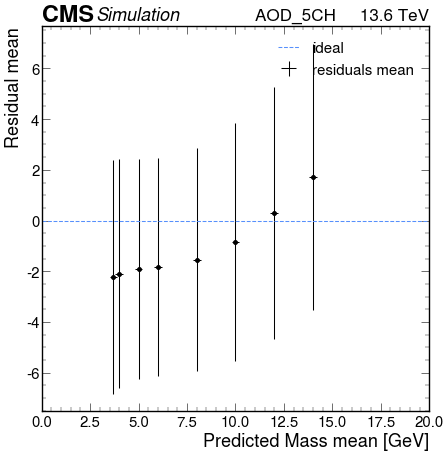

In [7]:
# def corrected_pred_mean_miniAOD_4(m):
#     mass = m + polynomial_mean_miniAOD_4(m)
#     return mass

# def corrected_pred_mean_miniAOD_5(m):
#     mass = m + polynomial_mean_miniAOD_5(m)
#     return mass
    
# def corrected_pred_mean_AOD_4(m):
#     mass = m + polynomial_mean_AOD_4(m)
#     return mass

# def corrected_pred_mean_AOD_5(m):
#     mass = m + polynomial_mean_AOD_5(m)
#     return mass


# m0_min= 0
# m0_max=20
# bin_size =0.4

# residuals_mean_miniAOD_4_c , residuals_std_miniAOD_4_c = [], []
# residuals_mean_miniAOD_5_c , residuals_std_miniAOD_5_c = [], []
# residuals_mean_AOD_4_c , residuals_std_AOD_4_c = [], []
# residuals_mean_AOD_5_c , residuals_std_AOD_5_c = [], []

# for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    
#     # if i >5: break 
#     data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
#     infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
#     data_miniAOD_4 = pickle.load(infile_miniAOD_4)
#     infile_miniAOD_4.close()
#     m_pred_miniAOD_4_c = corrected_pred_mean_miniAOD_4(data_miniAOD_4["m_pred"])
#     residual_m_pred_miniAOD_4_c = signals[i]- m_pred_miniAOD_4_c
#     residuals_mean_miniAOD_4_c.append(np.mean(residual_m_pred_miniAOD_4_c))
#     residuals_std_miniAOD_4_c.append(np.std(residual_m_pred_miniAOD_4_c))

#     data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
#     infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
#     data_miniAOD_5 = pickle.load(infile_miniAOD_5)
#     infile_miniAOD_5.close()
#     m_pred_miniAOD_5_c = corrected_pred_mean_miniAOD_5(data_miniAOD_5["m_pred"])
#     residual_m_pred_miniAOD_5_c = signals[i]- m_pred_miniAOD_5_c
#     residuals_mean_miniAOD_5_c.append(np.mean(residual_m_pred_miniAOD_5_c))
#     residuals_std_miniAOD_5_c.append(np.std(residual_m_pred_miniAOD_5_c))

#     data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
#     infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
#     data_AOD_4 = pickle.load(infile_AOD_4)
#     infile_AOD_4.close()
#     m_pred_AOD_4_c = corrected_pred_mean_AOD_4(data_AOD_4["m_pred"])
#     residual_m_pred_AOD_4_c = signals[i]- m_pred_AOD_4_c
#     residuals_mean_AOD_4_c.append(np.mean(residual_m_pred_AOD_4_c))
#     residuals_std_AOD_4_c.append(np.std(residual_m_pred_AOD_4_c))
    
#     data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
#     infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
#     data_AOD_5 = pickle.load(infile_AOD_5)
#     infile_AOD_5.close()
#     m_pred_AOD_5_c = corrected_pred_mean_AOD_5(data_AOD_5["m_pred"])
#     residual_m_pred_AOD_5_c = signals[i]- m_pred_AOD_5_c
#     residuals_mean_AOD_5_c.append(np.mean(residual_m_pred_AOD_5_c))
#     residuals_std_AOD_5_c.append(np.std(residual_m_pred_AOD_5_c))

# dpi_ =50
# fig, ax = plt.subplots(dpi=dpi_)   
# plt.scatter(signals, residuals_mean_miniAOD_4_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mean_miniAOD_4_c, xerr=0.2, yerr=residuals_std_miniAOD_4_c, fmt='none', color='black', label='residuals mean')
# # plt.plot(x,y_fit_mean, color='r',linestyle='--', label = f"fitted curve" )
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="miniAOD_4CH     13.6 TeV", loc=0, ax=ax)
# plt.show() 



# fig, ax = plt.subplots(dpi=dpi_)   
# plt.scatter(signals, residuals_mean_miniAOD_5_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mean_miniAOD_5_c, xerr=0.2, yerr=residuals_std_miniAOD_5_c, fmt='none', color='black', label='residuals mean')
# # plt.plot(x,y_fit_mean, color='r',linestyle='--', label = f"fitted curve" )
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="miniAOD_5CH     13.6 TeV", loc=0, ax=ax)
# plt.show() 

# fig, ax = plt.subplots(dpi=dpi_)   
# plt.scatter(signals, residuals_mean_AOD_4_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mean_AOD_4_c, xerr=0.2, yerr=residuals_std_AOD_4_c, fmt='none', color='black', label='residuals mean')
# # plt.plot(x,y_fit_mean, color='r',linestyle='--', label = f"fitted curve" )
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="AOD_4CH     13.6 TeV", loc=0, ax=ax)
# plt.show() 



# fig, ax = plt.subplots(dpi=dpi_)   
# plt.scatter(signals, residuals_mean_AOD_5_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mean_AOD_5_c, xerr=0.2, yerr=residuals_std_AOD_5_c, fmt='none', color='black', label='residuals mean')
# # plt.plot(x,y_fit_mean, color='r',linestyle='--', label = f"fitted curve" )
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="AOD_5CH     13.6 TeV", loc=0, ax=ax)
# plt.show() 

In [26]:
# print(coeff_mode_miniAOD_4)
# print(polynomial_mean_AOD_5)

          3            2
0.001185 x - 0.004992 x + 0.4098 x - 5.617


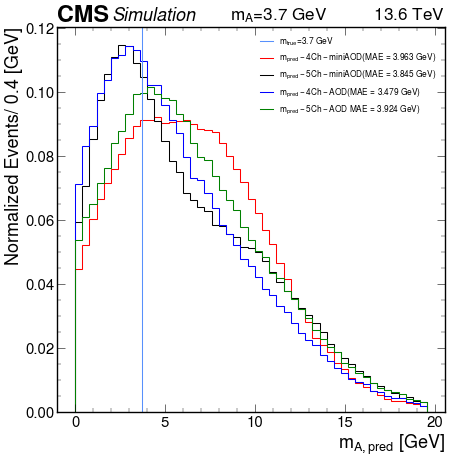

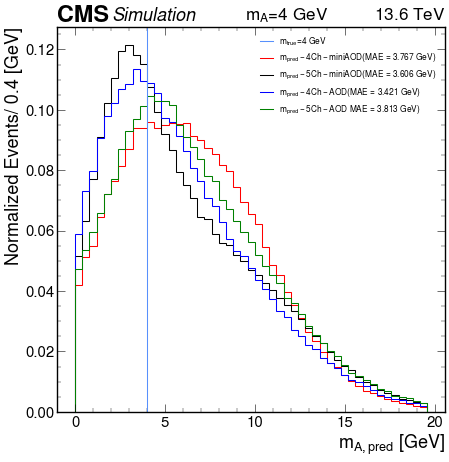

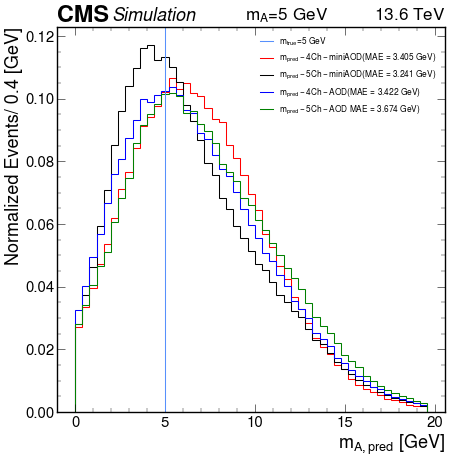

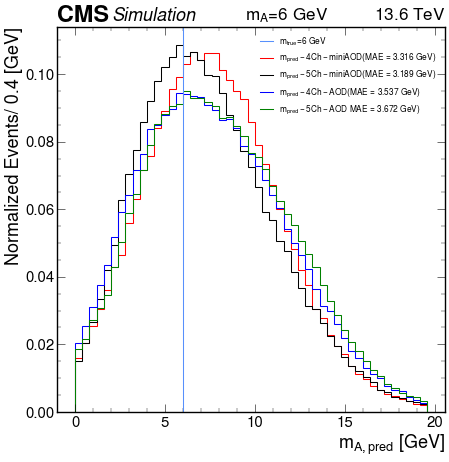

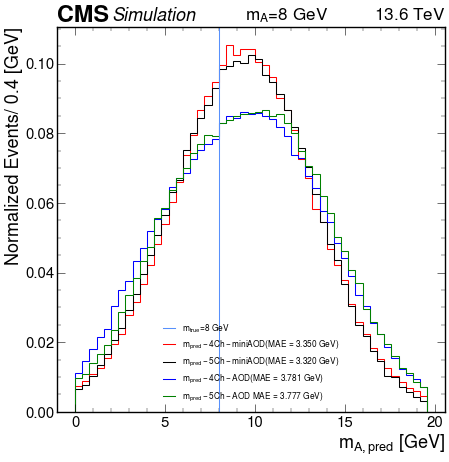

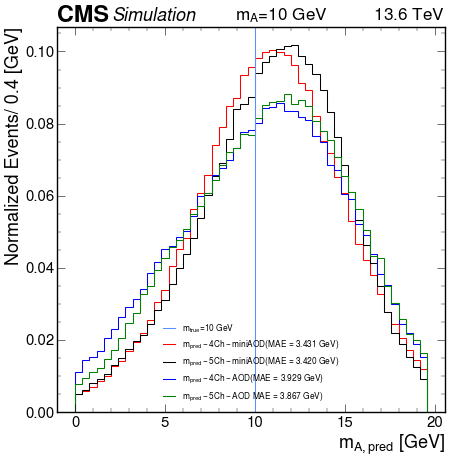

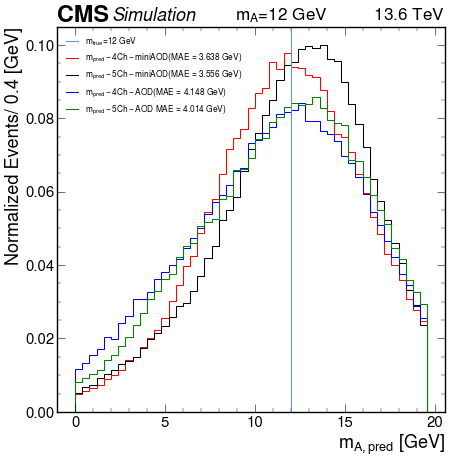

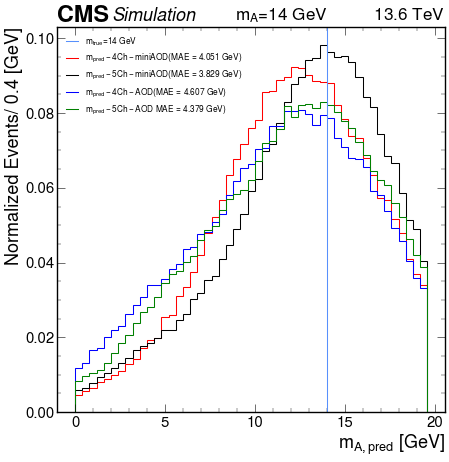

In [27]:
def corrected_pred_mean_miniAOD_4(m):
    mass = m + 0.003687 * m**3 - 0.07911 * m**2 + 1.047 * m - 7.214
    return mass

def corrected_pred_mean_miniAOD_5(m):
    mass = m + 0.004574 * m**3 - 0.1001 * m**2 + 1.121 * m - 6.977
    return mass
    
def corrected_pred_mean_AOD_4(m):
    mass = m  -6.215e-05 * m**3 + 0.03615 * m**2 - 0.004802 * m - 3.991
    return mass

def corrected_pred_mean_AOD_5(m):
    mass = m + 0.001185 * m**3 - 0.004992 * m**2 + 0.4098 * m - 5.617
    return mass



m0_min= 0
m0_max=20
bin_size =0.4
for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    # if i >5: break 
 
    data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
    infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
    data_miniAOD_4 = pickle.load(infile_miniAOD_4)
    infile_miniAOD_4.close()
    m_pred_miniAOD_4 = corrected_pred_mean_miniAOD_4(data_miniAOD_4["m_pred"])


    data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
    infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
    data_miniAOD_5 = pickle.load(infile_miniAOD_5)
    infile_miniAOD_5.close()
    m_pred_miniAOD_5 = corrected_pred_mean_miniAOD_5(data_miniAOD_5["m_pred"])

    data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
    infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
    data_AOD_4 = pickle.load(infile_AOD_4)
    infile_AOD_4.close()
    m_pred_AOD_4 = corrected_pred_mean_AOD_4(data_AOD_4["m_pred"])
    
    data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
    infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
    data_AOD_5 = pickle.load(infile_AOD_5)
    infile_AOD_5.close()
    m_pred_AOD_5 = corrected_pred_mean_AOD_5(data_AOD_5["m_pred"])


    dpi_ = 50
    fig, ax = plt.subplots(dpi=dpi_)
    plt.axvline(signals[i], label=r"$m_{true}$" + f"={signals[i]} GeV")
    h1=np.histogram(m_pred_miniAOD_4, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h1, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(signals[i] - m_pred_miniAOD_4)), color='red', density=True)
    h2=np.histogram(m_pred_miniAOD_5, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h2, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(signals[i] - m_pred_miniAOD_5)), linestyle='-', color='black', density=True)
    h3=np.histogram(m_pred_AOD_4, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h3, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-AOD$' + '(MAE = %.3f GeV)' %np.mean(np.abs(signals[i] - m_pred_AOD_4)), linestyle='-', color='blue', density=True)
    h4=np.histogram(m_pred_AOD_5, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h4, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-AOD$' + ' MAE = %.3f GeV)' %np.mean(np.abs(signals[i] - m_pred_AOD_5)), linestyle='-', color='green', density=True)
    plt.xlabel(r'$m_{A, pred}$ [GeV]')
    plt.ylabel('Normalized Events/ 0.4 [GeV]')
    plt.legend(loc='best', fontsize=12)
    hep.cms.label(llabel="Simulation", rlabel=f"$m_A$={signals[i]} GeV          "    +   "13.6 TeV", loc=0, ax=ax)
    signal_tag = f"{signals[i]}".replace('.', 'p')
    # plt.savefig(f'{out_dir}/signal_mass_{signal_tag}_inference_miniAOD_AOD_4_5_ch_comparision_corrected_by_residual_mean.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
    plt.show()

### Correction using residual mode using signal samples

In [9]:
def get_hist_mode(data, bins=len(np.arange(0,18.1,0.4))):
    counts, bin_edges = np.histogram(data, bins=bins)

    # Find the index of the mode bin
    mode_bin_index = np.argmax(counts)

    # Get the mode bin range
    mode_bin_start = bin_edges[mode_bin_index]
    mode_bin_end = bin_edges[mode_bin_index + 1]
    
    return (mode_bin_end + mode_bin_start)/2

def compute_uncertainty(data, n_bootstraps=1000):
    mode_bins = []

    for _ in range(n_bootstraps):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        counts, bin_edges = np.histogram(bootstrap_sample, bins=30)
        mode_bin_index = np.argmax(counts)
        mode_bin_start = bin_edges[mode_bin_index]
        mode_bin_end = bin_edges[mode_bin_index + 1]
        mode_bins.append((mode_bin_start + mode_bin_end) / 2)

    return np.std(mode_bins)

def find_convergence(data, initial_bootstraps=1000, max_bootstraps=10000, step=1000, threshold=0.01):
    n_bootstraps = initial_bootstraps
    prev_uncertainty = compute_uncertainty(data, n_bootstraps)
    uncertainties = [(n_bootstraps, prev_uncertainty)]
    
    while n_bootstraps <= max_bootstraps:
        n_bootstraps += step
        current_uncertainty = compute_uncertainty(data, n_bootstraps)
        uncertainties.append((n_bootstraps, current_uncertainty))
        
        # Check for convergence
        if abs(current_uncertainty - prev_uncertainty) < threshold:
            print(f"Converged after {n_bootstraps} bootstraps.")
            break
            
        prev_uncertainty = current_uncertainty
    
    return prev_uncertainty, n_bootstraps







m0_min= 0
m0_max=20
bin_size =0.4

residuals_mode_miniAOD_4 , mode_errors_miniAOD_4= [], []
residuals_mode_miniAOD_5 , mode_errors_miniAOD_5= [], []
residuals_mode_AOD_4 , mode_errors_AOD_4= [], []
residuals_mode_AOD_5 , mode_errors_AOD_5= [], []

for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    
 
    data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
    infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
    data_miniAOD_4 = pickle.load(infile_miniAOD_4)
    infile_miniAOD_4.close()
    m_pred_miniAOD_4 = data_miniAOD_4["m_pred"]
    residuals_m_pred_miniAOD_4 = signals[i]- m_pred_miniAOD_4
    residuals_mode_miniAOD_4.append(get_hist_mode(residuals_m_pred_miniAOD_4))
    uncertainty_miniAOD_4, n_bootstraps_miniAOD_4 = find_convergence(residuals_m_pred_miniAOD_4.flatten())
    mode_errors_miniAOD_4.append(uncertainty_miniAOD_4)
    

    data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
    infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
    data_miniAOD_5 = pickle.load(infile_miniAOD_5)
    infile_miniAOD_5.close()
    m_pred_miniAOD_5 = data_miniAOD_5["m_pred"]
    residuals_m_pred_miniAOD_5 = signals[i]- m_pred_miniAOD_5
    residuals_mode_miniAOD_5.append(get_hist_mode(residuals_m_pred_miniAOD_5))
    uncertainty_miniAOD_5, n_bootstraps_miniAOD_5 = find_convergence(residuals_m_pred_miniAOD_5.flatten())
    mode_errors_miniAOD_5.append(uncertainty_miniAOD_5)

    data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
    infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
    data_AOD_4 = pickle.load(infile_AOD_4)
    infile_AOD_4.close()
    m_pred_AOD_4 = data_AOD_4["m_pred"]
    residuals_m_pred_AOD_4 = signals[i]- m_pred_AOD_4
    residuals_mode_AOD_4.append(get_hist_mode(residuals_m_pred_AOD_4))
    uncertainty_AOD_4, n_bootstraps_AOD_4 = find_convergence(residuals_m_pred_AOD_4.flatten())
    mode_errors_AOD_4.append(uncertainty_AOD_4)
    
    data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
    infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
    data_AOD_5 = pickle.load(infile_AOD_5)
    infile_AOD_5.close()
    m_pred_AOD_5 = data_AOD_5["m_pred"]
    residuals_m_pred_AOD_5 = signals[i]- m_pred_AOD_5
    residuals_mode_AOD_5.append(get_hist_mode(residuals_m_pred_AOD_5))
    uncertainty_AOD_5, n_bootstraps_AOD_5 = find_convergence(residuals_m_pred_AOD_5.flatten())
    mode_errors_AOD_5.append(uncertainty_AOD_5)


    
   




Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged 

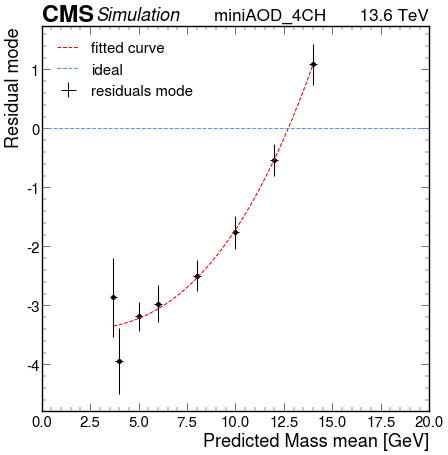

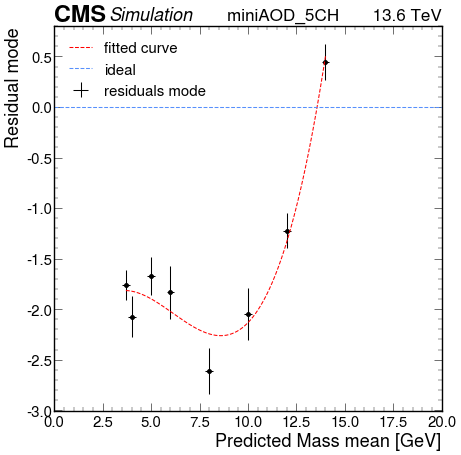

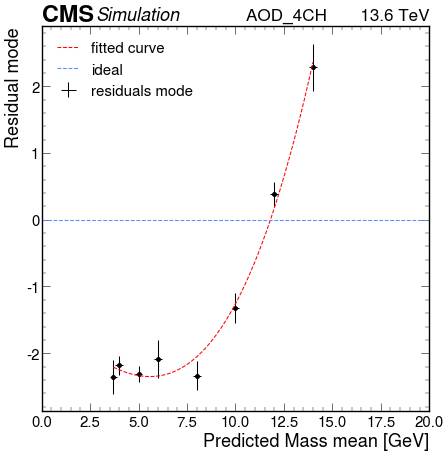

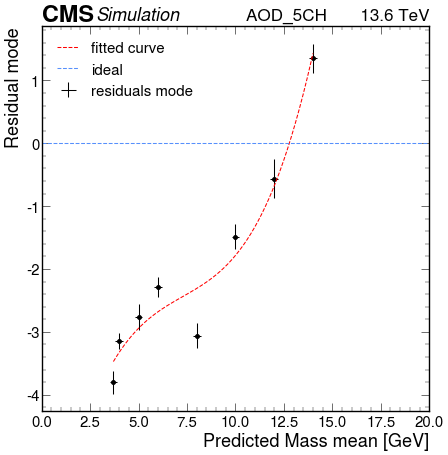

In [10]:
degree_mode = 3
dpi_ = 50
fig, ax = plt.subplots(dpi=dpi_)   
coeff_mode_miniAOD_4 = np.polyfit(signals, residuals_mode_miniAOD_4, degree_mode)
polynomial_mode_miniAOD_4 = np.poly1d(coeff_mode_miniAOD_4)
x = np.linspace(min(signals),max(signals), num=1000)
y_fit_mode_miniAOD_4 = polynomial_mode_miniAOD_4(x)
plt.scatter(signals, residuals_mode_miniAOD_4, color='black',marker='o')
plt.errorbar(signals, residuals_mode_miniAOD_4, xerr=0.2, yerr=mode_errors_miniAOD_4, fmt='none', color='black', label='residuals mode')
plt.plot(x,y_fit_mode_miniAOD_4, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mode")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="miniAOD_4CH       13.6 TeV", loc=0, ax=ax)
plt.show() 

fig, ax = plt.subplots(dpi=dpi_)   
coeff_mode_miniAOD_5 = np.polyfit(signals, residuals_mode_miniAOD_5, degree_mode)
polynomial_mode_miniAOD_5 = np.poly1d(coeff_mode_miniAOD_5)
y_fit_mode_miniAOD_5 = polynomial_mode_miniAOD_5(x)
plt.scatter(signals, residuals_mode_miniAOD_5, color='black',marker='o')
plt.errorbar(signals, residuals_mode_miniAOD_5, xerr=0.2, yerr=mode_errors_miniAOD_5, fmt='none', color='black', label='residuals mode')
plt.plot(x,y_fit_mode_miniAOD_5, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mode")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="miniAOD_5CH       13.6 TeV", loc=0, ax=ax)
plt.show()


fig, ax = plt.subplots(dpi=dpi_)   
coeff_mode_AOD_4 = np.polyfit(signals, residuals_mode_AOD_4, degree_mode)
polynomial_mode_AOD_4 = np.poly1d(coeff_mode_AOD_4)
y_fit_mode_AOD_4 = polynomial_mode_AOD_4(x)
plt.scatter(signals, residuals_mode_AOD_4, color='black',marker='o')
plt.errorbar(signals, residuals_mode_AOD_4, xerr=0.2, yerr=mode_errors_AOD_4, fmt='none', color='black', label='residuals mode')
plt.plot(x,y_fit_mode_AOD_4, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mode")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="AOD_4CH       13.6 TeV", loc=0, ax=ax)
plt.show()

fig, ax = plt.subplots(dpi=dpi_)   
coeff_mode_AOD_5 = np.polyfit(signals, residuals_mode_AOD_5, degree_mode)
polynomial_mode_AOD_5 = np.poly1d(coeff_mode_AOD_5)
y_fit_mode_AOD_5 = polynomial_mode_AOD_5(x)
plt.scatter(signals, residuals_mode_AOD_5, color='black',marker='o')
plt.errorbar(signals, residuals_mode_AOD_5, xerr=0.2, yerr=mode_errors_AOD_5, fmt='none', color='black', label='residuals mode')
plt.plot(x,y_fit_mode_AOD_5, color='r',linestyle='--', label = f"fitted curve" )
plt.xlim(0,20)
plt.axhline(y=0, linestyle='--', label="ideal")
plt.xlabel("Predicted Mass mean [GeV]")
plt.ylabel("Residual mode")
plt.legend()
plt.legend(loc='best')
hep.cms.label(llabel="Simulation", rlabel="AOD_5CH       13.6 TeV", loc=0, ax=ax)
plt.show()

Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 3000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 3000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 4000 bootstraps.
Converged after 2000 bootstraps.
Converged after 3000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 3000 bootstraps.
Converged after 2000 bootstraps.
Converged after 4000 bootstraps.
Converged after 2000 bootstraps.
Converged after 2000 bootstraps.
Converged after 3000 bootstraps.
Converged 

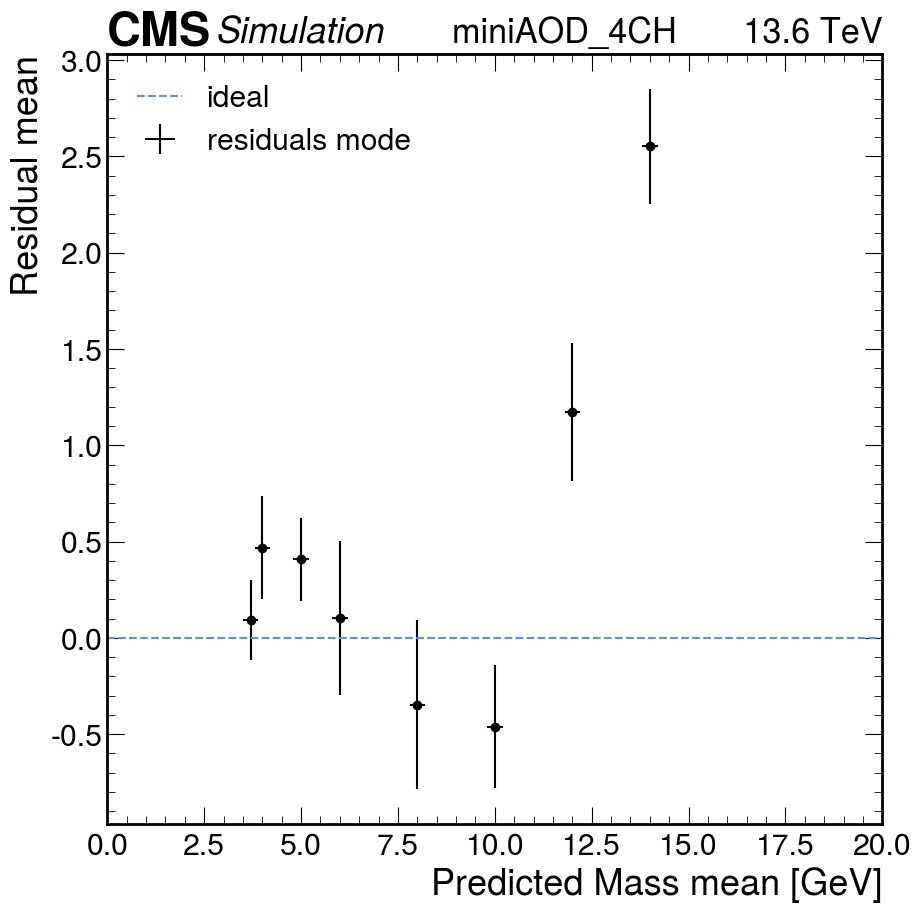

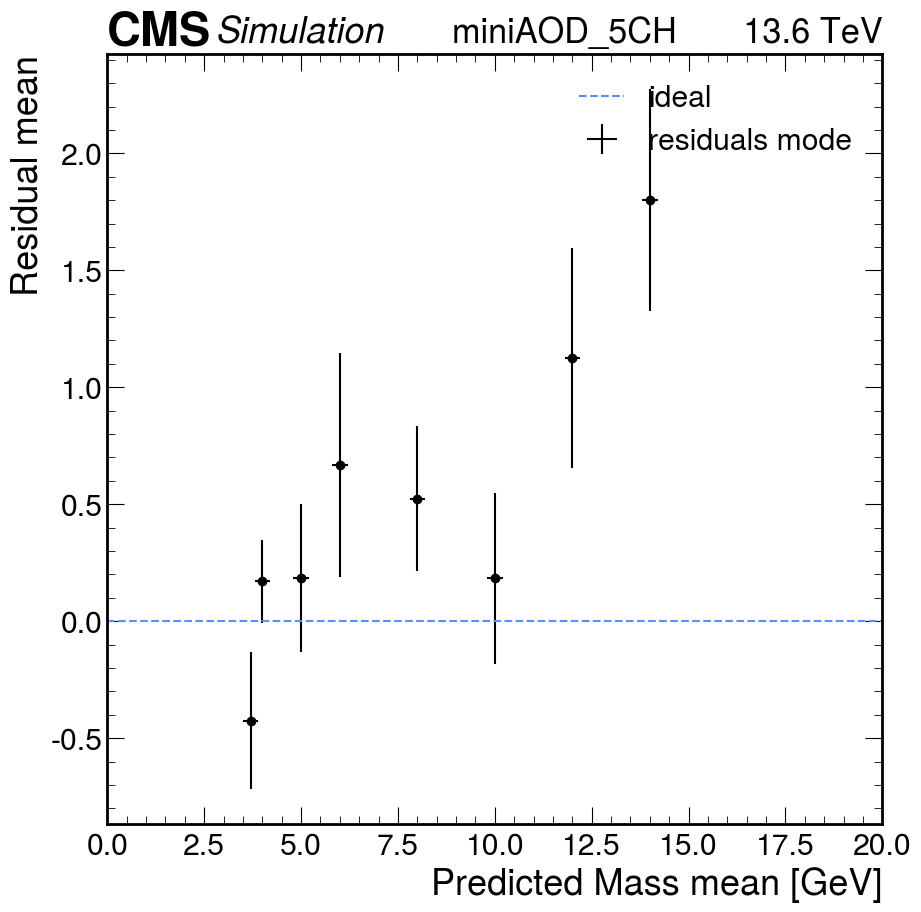

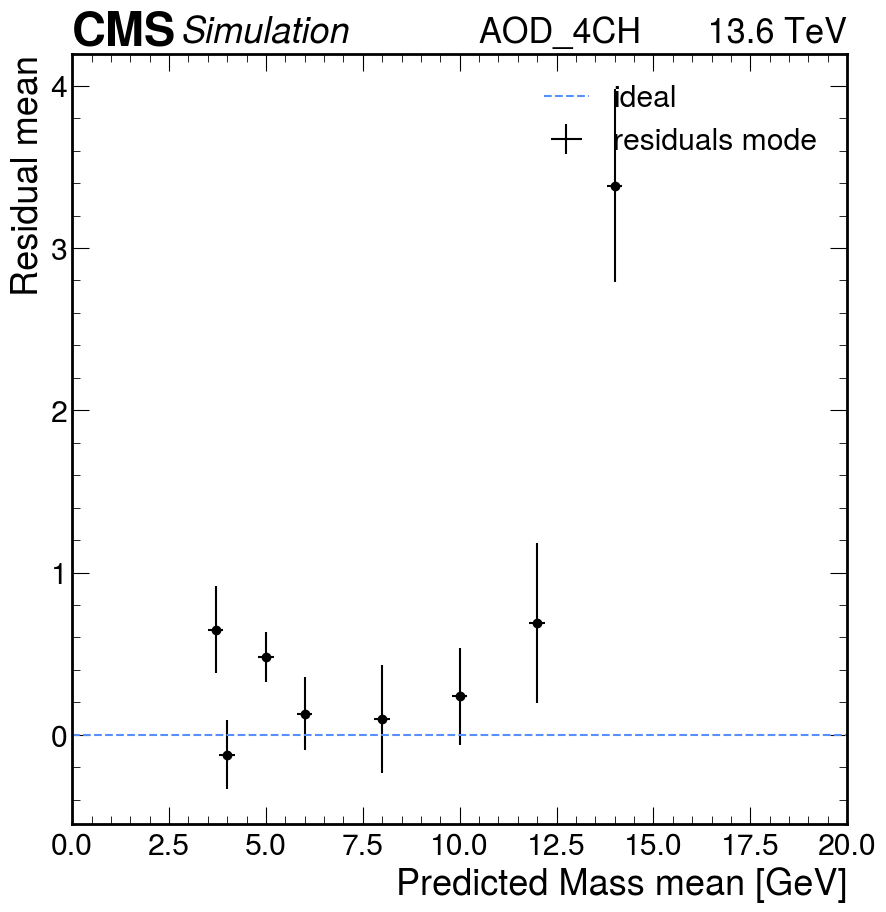

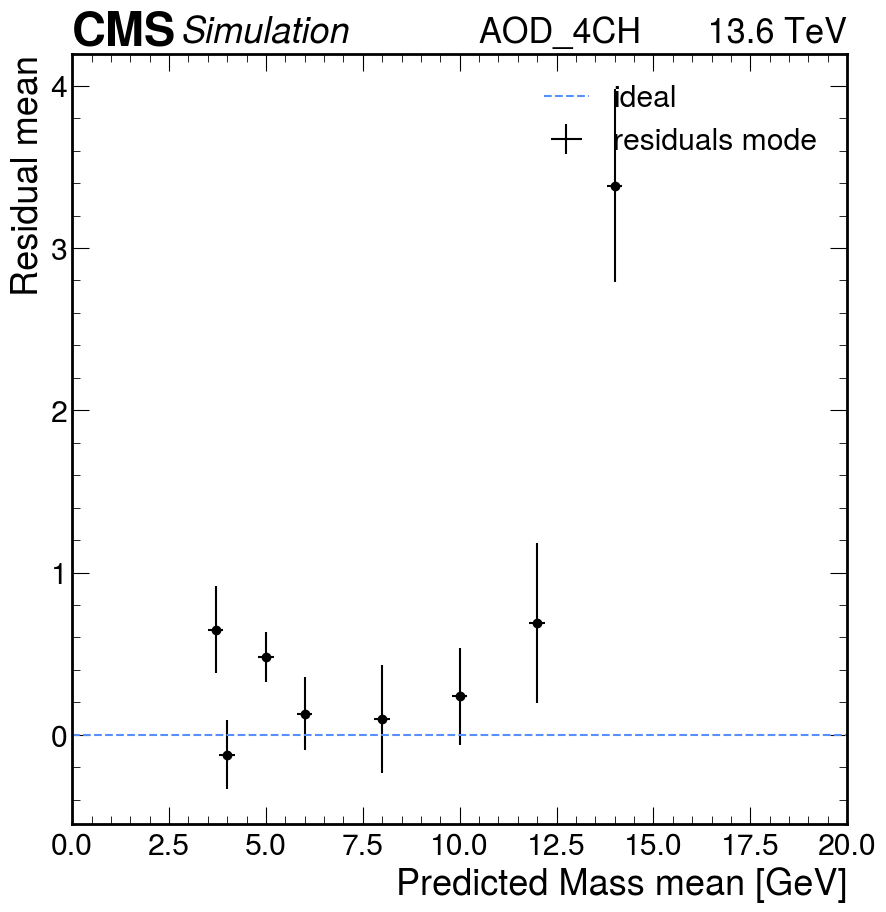

In [25]:
# def corrected_pred_mode_miniAOD_4(m):
#     mass = m + polynomial_mode_miniAOD_4(m)
#     return mass

# def corrected_pred_mode_miniAOD_5(m):
#     mass = m + polynomial_mode_miniAOD_5(m)
#     return mass

# def corrected_pred_mode_AOD_4(m):
#     mass = m + polynomial_mode_AOD_4(m)
#     return mass

# def corrected_pred_mode_AOD_5(m):
#     mass = m + polynomial_mode_AOD_5(m)
#     return mass
    
# m0_min= 0
# m0_max=20
# bin_size =0.4
# residuals_mode_miniAOD_4_c , mode_errors_miniAOD_4_c = [], []
# residuals_mode_miniAOD_5_c , mode_errors_miniAOD_5_c = [], []
# residuals_mode_AOD_4_c , mode_errors_AOD_4_c = [], []
# residuals_mode_AOD_5_c , mode_errors_AOD_5_c = [], []
# for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    
 
#     data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
#     infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
#     data_miniAOD_4 = pickle.load(infile_miniAOD_4)
#     infile_miniAOD_4.close()
#     m_pred_miniAOD_4 = corrected_pred_mode_miniAOD_4(data_miniAOD_4["m_pred"])
#     residuals_m_pred_miniAOD_4_c = signals[i]- m_pred_miniAOD_4
#     residuals_mode_miniAOD_4_c.append(get_hist_mode(residuals_m_pred_miniAOD_4_c))
#     uncertainty_miniAOD_4_c, n_bootstraps_miniAOD_4_c = find_convergence(residuals_m_pred_miniAOD_4_c.flatten())
#     mode_errors_miniAOD_4_c.append(uncertainty_miniAOD_4_c)

#     data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
#     infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
#     data_miniAOD_5 = pickle.load(infile_miniAOD_5)
#     infile_miniAOD_5.close()
#     m_pred_miniAOD_5 = corrected_pred_mode_miniAOD_5(data_miniAOD_5["m_pred"])
#     residuals_m_pred_miniAOD_5_c = signals[i]- m_pred_miniAOD_5
#     residuals_mode_miniAOD_5_c.append(get_hist_mode(residuals_m_pred_miniAOD_5_c))
#     uncertainty_miniAOD_5_c, n_bootstraps_miniAOD_5_c = find_convergence(residuals_m_pred_miniAOD_5_c.flatten())
#     mode_errors_miniAOD_5_c.append(uncertainty_miniAOD_5_c)

#     data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
#     infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
#     data_AOD_4 = pickle.load(infile_AOD_4)
#     infile_AOD_4.close()
#     m_pred_AOD_4 = corrected_pred_mode_AOD_4(data_AOD_4["m_pred"])
#     residuals_m_pred_AOD_4_c = signals[i]- m_pred_AOD_4
#     residuals_mode_AOD_4_c.append(get_hist_mode(residuals_m_pred_AOD_4_c))
#     uncertainty_AOD_4_c, n_bootstraps_AOD_4_c = find_convergence(residuals_m_pred_AOD_4_c.flatten())
#     mode_errors_AOD_4_c.append(uncertainty_AOD_4_c)

#     data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
#     infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
#     data_AOD_5 = pickle.load(infile_AOD_5)
#     infile_AOD_5.close()
#     m_pred_AOD_5 = corrected_pred_mode_AOD_5(data_AOD_5["m_pred"])
#     residuals_m_pred_AOD_5_c = signals[i]- m_pred_AOD_5
#     residuals_mode_AOD_5_c.append(get_hist_mode(residuals_m_pred_AOD_5_c))
#     uncertainty_AOD_5_c, n_bootstraps_AOD_5_c = find_convergence(residuals_m_pred_AOD_5_c.flatten())
#     mode_errors_AOD_5_c.append(uncertainty_AOD_5_c)

# fig, ax = plt.subplots()   
# plt.scatter(signals, residuals_mode_miniAOD_4_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mode_miniAOD_4_c, xerr=0.2, yerr=mode_errors_miniAOD_4_c, fmt='none', color='black', label='residuals mode')
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="miniAOD_4CH       13.6 TeV", loc=0, ax=ax)
# plt.show() 


# fig, ax = plt.subplots()   
# plt.scatter(signals, residuals_mode_miniAOD_5_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mode_miniAOD_5_c, xerr=0.2, yerr=mode_errors_miniAOD_5_c, fmt='none', color='black', label='residuals mode')
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="miniAOD_5CH       13.6 TeV", loc=0, ax=ax)
# plt.show() 


# fig, ax = plt.subplots()   
# plt.scatter(signals, residuals_mode_AOD_4_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mode_AOD_4_c, xerr=0.2, yerr=mode_errors_AOD_4_c, fmt='none', color='black', label='residuals mode')
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="AOD_4CH       13.6 TeV", loc=0, ax=ax)
# plt.show() 

# fig, ax = plt.subplots()   
# plt.scatter(signals, residuals_mode_AOD_4_c, color='black',marker='o')
# plt.errorbar(signals, residuals_mode_AOD_4_c, xerr=0.2, yerr=mode_errors_AOD_4_c, fmt='none', color='black', label='residuals mode')
# plt.xlim(0,20)
# plt.axhline(y=0, linestyle='--', label="ideal")
# plt.xlabel("Predicted Mass mean [GeV]")
# plt.ylabel("Residual mean")
# plt.legend()
# plt.legend(loc='best')
# hep.cms.label(llabel="Simulation", rlabel="AOD_4CH       13.6 TeV", loc=0, ax=ax)
# plt.show() 

In [22]:
residuals_mode_miniAOD_4_c

[np.float64(0.09158696429375546),
 np.float64(0.467738113847334),
 np.float64(0.4070203333694522),
 np.float64(0.1035092657036838),
 np.float64(-0.3463361671835159),
 np.float64(-0.461285926232998),
 np.float64(1.1720507594756846),
 np.float64(2.5513356243498375)]

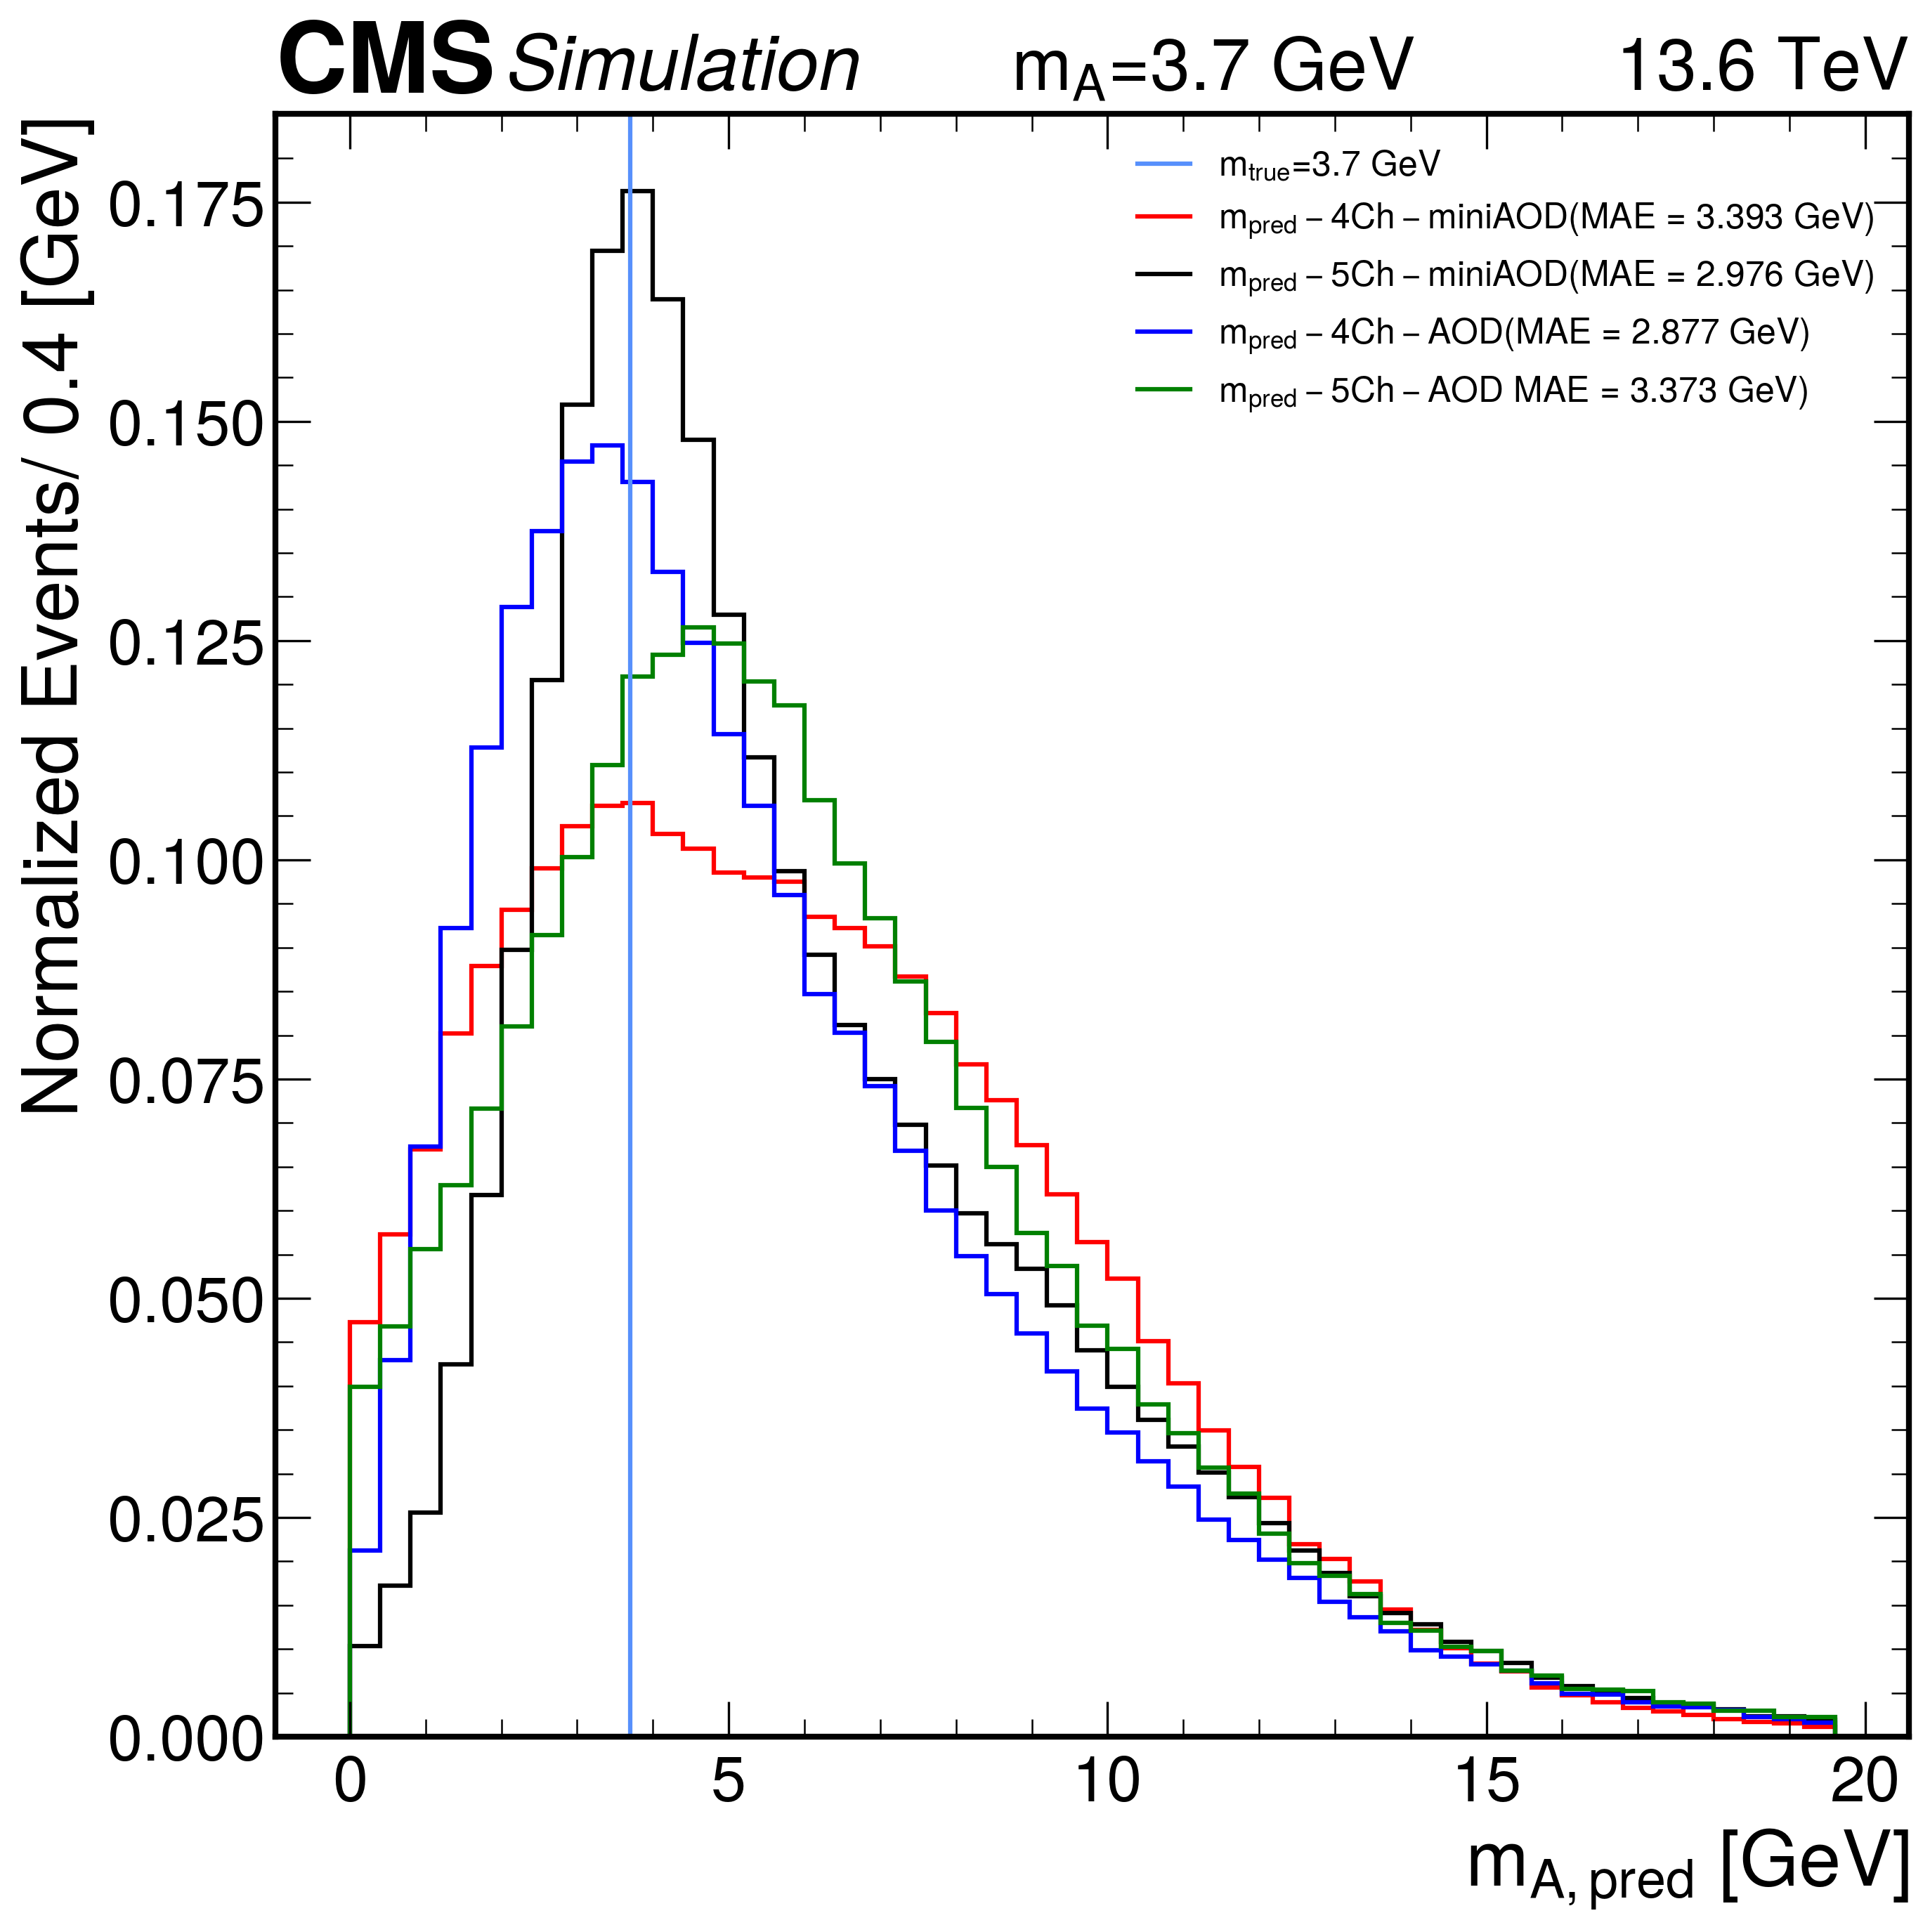

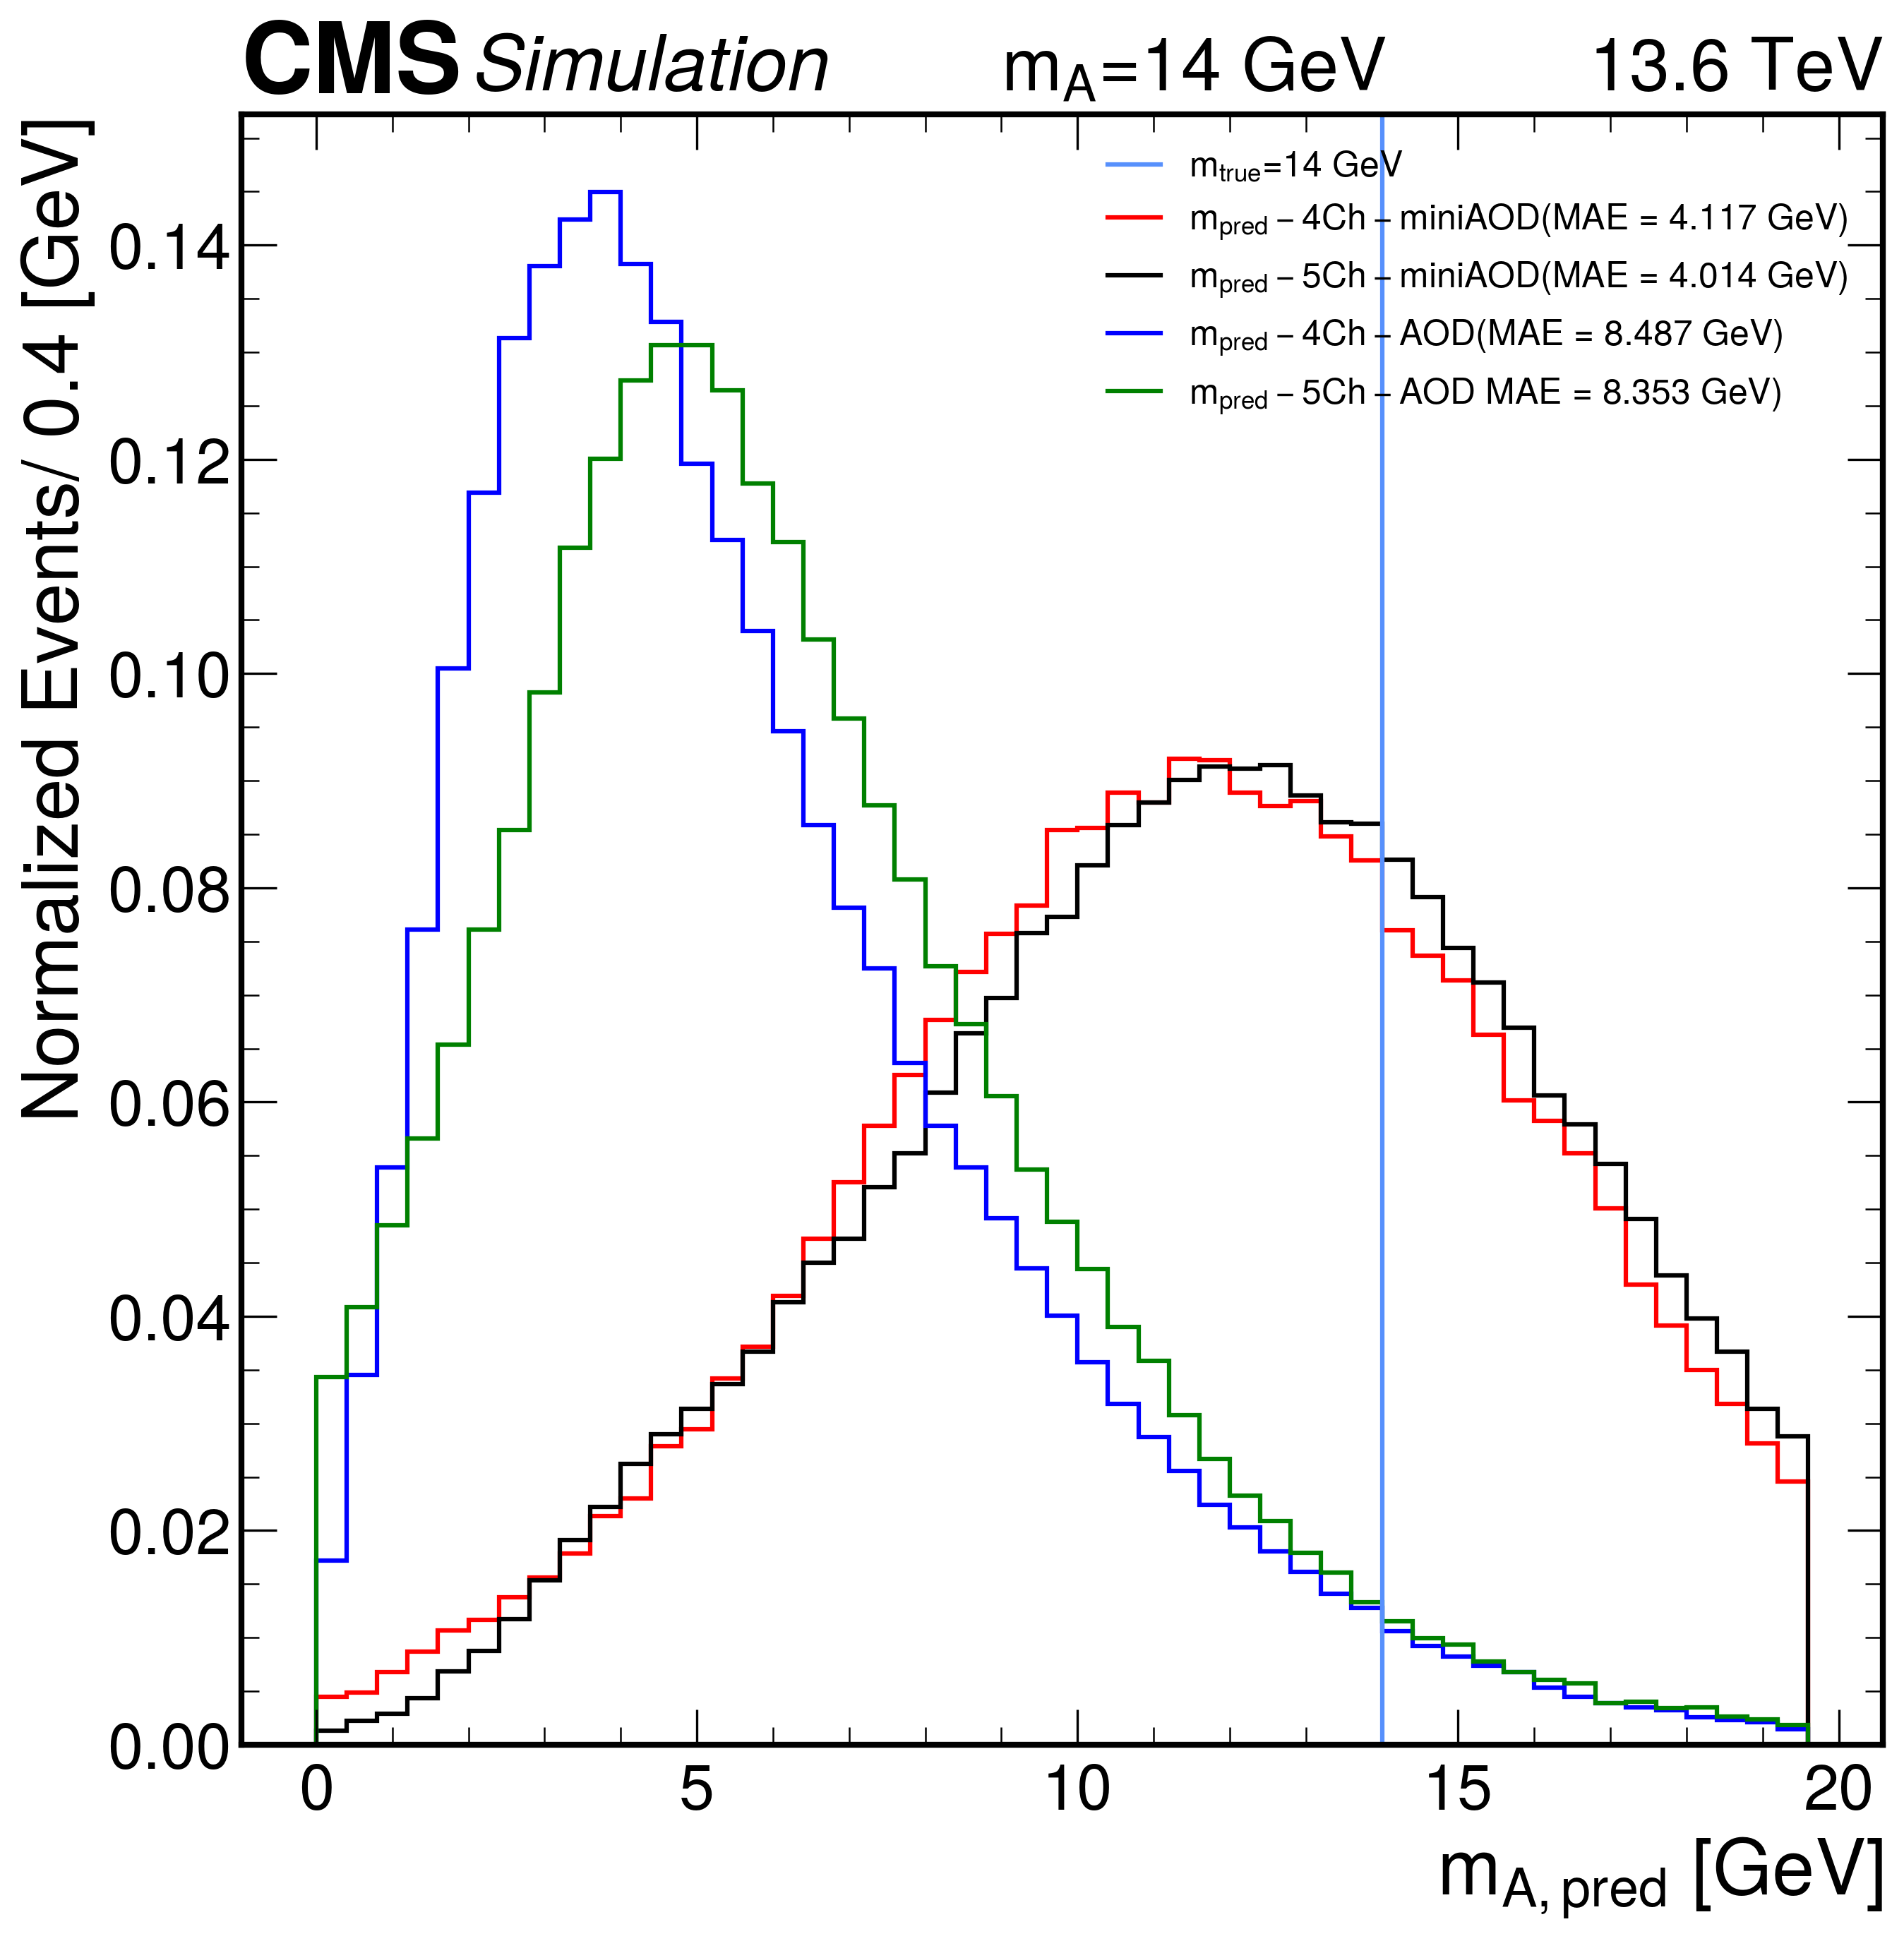

In [45]:
def corrected_pred_mode_miniAOD_4(m):
    mass = m + 0.001178 * m**3 + 0.009921 * m**2 - 0.05361 * m - 3.347
    return mass


def corrected_pred_mode_miniAOD_5(m):
    mass = m + 0.007372 * m**3 - 0.1353 * m**2 + 0.6927 * m - 2.9
    return mass

def corrected_pred_mode_AOD_4(m):
    mass = m + 0.002651 * m**3 - 0.0001932 * m**2 - 0.246 * m - 1.431
    return mass

def corrected_pred_mode_AOD_5(m):
    mass = m + 0.008876 * m**3 - 0.1939 * m**2 + 1.586 * m - 7.136
    return mass



m0_min= 0
m0_max=20
bin_size =0.4
for i, (signal_file_miniAOD, signal_file_AOD) in enumerate(zip(signal_files_miniAOD, signal_files_AOD)):
    
 
    data_file_miniAOD_4 = glob.glob(f"{in_dir}/{ResNet_miniAOD_4}/{signal_file_miniAOD}")[0]
    infile_miniAOD_4 = open(f"{data_file_miniAOD_4}", "rb")
    data_miniAOD_4 = pickle.load(infile_miniAOD_4)
    infile_miniAOD_4.close()
    m_pred_miniAOD_4 = corrected_pred_mode_miniAOD_4(data_miniAOD_4["m_pred"])


    data_file_miniAOD_5 = glob.glob(f"{in_dir}/{ResNet_miniAOD_5}/{signal_file_miniAOD}")[0]
    infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
    data_miniAOD_5 = pickle.load(infile_miniAOD_5)
    infile_miniAOD_5.close()
    m_pred_miniAOD_5 = corrected_pred_mode_miniAOD_5(data_miniAOD_5["m_pred"])

    data_file_AOD_4 = glob.glob(f"{in_dir}/{ResNet_AOD_4}/{signal_file_AOD}")[0]
    infile_AOD_4 = open(f"{data_file_AOD_4}", "rb")
    data_AOD_4 = pickle.load(infile_AOD_4)
    infile_AOD_4.close()
    m_pred_AOD_4 = corrected_pred_mode_AOD_4(data_AOD_4["m_pred"])
    
    data_file_AOD_5 = glob.glob(f"{in_dir}/{ResNet_AOD_5}/{signal_file_AOD}")[0]
    infile_AOD_5 = open(f"{data_file_AOD_5}", "rb")
    data_AOD_5 = pickle.load(infile_AOD_5)
    infile_AOD_5.close()
    m_pred_AOD_5 = corrected_pred_mode_AOD_5(data_AOD_5["m_pred"])


    dpi_ =300
    fig, ax = plt.subplots(dpi=dpi_)
    plt.axvline(signals[i], label=r"$m_{true}$" + f"={signals[i]} GeV")
    h1=np.histogram(m_pred_miniAOD_4, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h1, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(signals[i] - m_pred_miniAOD_4)), color='red', density=True)
    h2=np.histogram(m_pred_miniAOD_5, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h2, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(signals[i] - m_pred_miniAOD_5)), linestyle='-', color='black', density=True)
    h3=np.histogram(m_pred_AOD_4, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h3, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-AOD$' + '(MAE = %.3f GeV)' %np.mean(np.abs(signals[i] - m_pred_AOD_4)), linestyle='-', color='blue', density=True)
    h4=np.histogram(m_pred_AOD_5, bins=np.arange(m0_min,m0_max,bin_size))
    hep.histplot(h4, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-AOD$' + ' MAE = %.3f GeV)' %np.mean(np.abs(signals[i] - m_pred_AOD_5)), linestyle='-', color='green', density=True)
    plt.xlabel(r'$m_{A, pred}$ [GeV]')
    plt.ylabel('Normalized Events/ 0.4 [GeV]')
    plt.legend(loc='best', fontsize=12)
    hep.cms.label(llabel="Simulation", rlabel=f"$m_A$={signals[i]} GeV          "    +   "13.6 TeV", loc=0, ax=ax)
    signal_tag = f"{signals[i]}".replace('.', 'p')
    # plt.savefig(f'{out_dir}/signal_mass_{signal_tag}_inference_miniAOD_AOD_4_5_ch_comparision_correct_by_residual_mode.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
    plt.show()

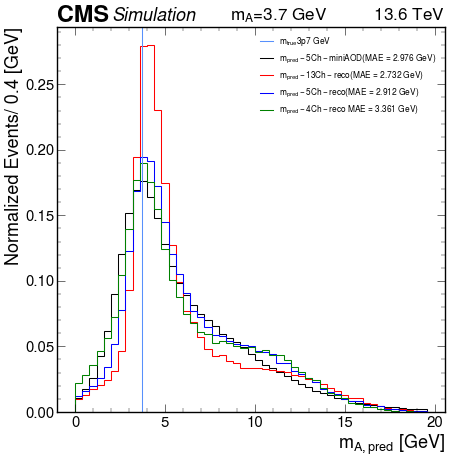

In [53]:
def correction(mass_raw,a=-0.04922334  ,b=-1.25575772):
            # mass = m + polynomial_mode(m)
            mass = mass_raw + a*mass_raw + b
            return mass
    

def corrected_pred_mode_miniAOD_5(m):
    mass = m + 0.007372 * m**3 - 0.1353 * m**2 + 0.6927 * m - 2.9
    return mass 
    
miniAOD_5_3p7 = "../analysis_run3/Data_for_plots/ResNet_mapA_signal_backgrounds_5_ch_inference_miniAOD/IMG_signal_mass_3p7_GeV_miniAOD_combined.pkl"
miniAOD_5_14 = "../analysis_run3/Data_for_plots/ResNet_mapA_signal_backgrounds_5_ch_inference_miniAOD/IMG_signal_mass_14_GeV_miniAOD_combined.pkl"   

reco_13_3p7 = "../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new/ResNet_mapA_mN1p2To22_unbaised/13_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy_HBHE_energy_Pix_1_Pix_2_Pix_3_Pix_4_Tib_1_Tib_2_Tob_1_Tob_2/signal_3p7_epoch_100_inference_data.pkl"
reco_13_14 = "../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new/ResNet_mapA_mN1p2To22_unbaised/13_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy_HBHE_energy_Pix_1_Pix_2_Pix_3_Pix_4_Tib_1_Tib_2_Tob_1_Tob_2/signal_14_epoch_100_inference_data.pkl"

reco_5_3p7  = "../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new/ResNet_mapA_mN1p2To22_unbaised/5_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy_HBHE_energy/signal_3p7_epoch_100_inference_data.pkl"
reco_5_14 = "../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new/ResNet_mapA_mN1p2To22_unbaised/5_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy_HBHE_energy/signal_14_epoch_100_inference_data.pkl"

reco_4_3p7 = "../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new/ResNet_mapA_mN1p2To22_unbaised/4_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy/signal_3p7_epoch_100_inference_data.pkl"
reco_4_14 = "../analysis_run3/Data_for_plots/mass_regression_test_data/jupyter_notebook_new/ResNet_mapA_mN1p2To22_unbaised/4_ResNet_mapA_Tracks_pt_Tracks_dZSig_Tracks_d0Sig_ECAL_energy/signal_14_epoch_100_inference_data.pkl"


data_file_miniAOD_5 = miniAOD_5_3p7
infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
data_miniAOD_5 = pickle.load(infile_miniAOD_5)
infile_miniAOD_5.close()
m_pred_miniAOD_5 = corrected_pred_mode_miniAOD_5(data_miniAOD_5["m_pred"])


data_file_reco_13 = reco_13_3p7
infile_reco_13 = open(f"{data_file_reco_13}", "rb")
data_reco_13 = pickle.load(infile_reco_13)
infile_reco_13.close()
m_pred_reco_13 = correction(data_reco_13["m_pred"])

data_file_reco_5 = reco_5_3p7
infile_reco_5 = open(f"{data_file_reco_5}", "rb")
data_reco_5 = pickle.load(infile_reco_5)
infile_reco_5.close()
m_pred_reco_5 = correction(data_reco_5["m_pred"])

data_file_reco_4 = reco_4_3p7
infile_reco_4 = open(f"{data_file_reco_4}", "rb")
data_reco_4 = pickle.load(infile_reco_4)
infile_reco_4.close()
m_pred_reco_4 = correction(data_reco_4["m_pred"])

dpi_ =50
fig, ax = plt.subplots(dpi=dpi_)
plt.axvline(3.7, label=r"$m_{true}$" + f"3p7 GeV")
h1=np.histogram(m_pred_miniAOD_5, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h1, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(3.7 - m_pred_miniAOD_5)), color='black', density=True)
h2=np.histogram(m_pred_reco_13, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h2, histtype='step', yerr=False, label=r'$m_{pred} -13 Ch-reco$' + '(MAE = %.3f GeV)'%np.mean(np.abs(3.7 - m_pred_reco_13)), linestyle='-', color='red', density=True)
h3=np.histogram(m_pred_reco_5, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h3, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-reco$' + '(MAE = %.3f GeV)' %np.mean(np.abs(3.7 - m_pred_AOD_4)), linestyle='-', color='blue', density=True)
h4=np.histogram(m_pred_reco_4, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h4, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-reco$' + ' MAE = %.3f GeV)' %np.mean(np.abs(3.7 - m_pred_AOD_5)), linestyle='-', color='green', density=True)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Normalized Events/ 0.4 [GeV]')
plt.legend(loc='best', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f"$m_A$={3.7} GeV          "    +   "13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/signal_mass_3p7_inference_miniAOD_5_ch_reco_13_5_4_ch_comparision.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()

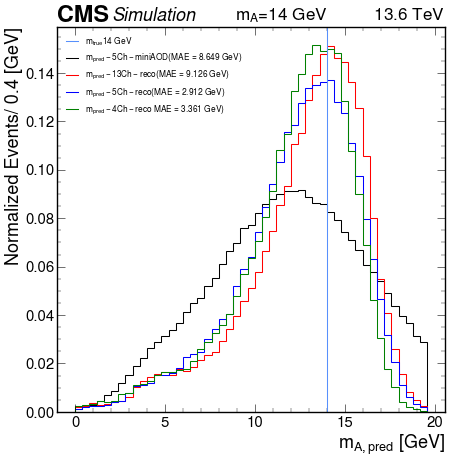

In [51]:
data_file_miniAOD_5 = miniAOD_5_14
infile_miniAOD_5 = open(f"{data_file_miniAOD_5}", "rb")
data_miniAOD_5 = pickle.load(infile_miniAOD_5)
infile_miniAOD_5.close()
m_pred_miniAOD_5 = corrected_pred_mode_miniAOD_5(data_miniAOD_5["m_pred"])


data_file_reco_13 = reco_13_14
infile_reco_13 = open(f"{data_file_reco_13}", "rb")
data_reco_13 = pickle.load(infile_reco_13)
infile_reco_13.close()
m_pred_reco_13 = correction(data_reco_13["m_pred"])

data_file_reco_5 = reco_5_14
infile_reco_5 = open(f"{data_file_reco_5}", "rb")
data_reco_5 = pickle.load(infile_reco_5)
infile_reco_5.close()
m_pred_reco_5 = correction(data_reco_5["m_pred"])

data_file_reco_4 = reco_4_14
infile_reco_4 = open(f"{data_file_reco_4}", "rb")
data_reco_4 = pickle.load(infile_reco_4)
infile_reco_4.close()
m_pred_reco_4 = correction(data_reco_4["m_pred"])

dpi_ =50
fig, ax = plt.subplots(dpi=dpi_)
plt.axvline(14, label=r"$m_{true}$" + f"14 GeV")
h1=np.histogram(m_pred_miniAOD_5, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h1, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-miniAOD$' + '(MAE = %.3f GeV)'%np.mean(np.abs(3.7 - m_pred_miniAOD_5)), color='black', density=True)
h2=np.histogram(m_pred_reco_13, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h2, histtype='step', yerr=False, label=r'$m_{pred} -13 Ch-reco$' + '(MAE = %.3f GeV)'%np.mean(np.abs(3.7 - m_pred_reco_13)), linestyle='-', color='red', density=True)
h3=np.histogram(m_pred_reco_5, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h3, histtype='step', yerr=False, label=r'$m_{pred} -5 Ch-reco$' + '(MAE = %.3f GeV)' %np.mean(np.abs(3.7 - m_pred_AOD_4)), linestyle='-', color='blue', density=True)
h4=np.histogram(m_pred_reco_4, bins=np.arange(m0_min,m0_max,bin_size))
hep.histplot(h4, histtype='step', yerr=False, label=r'$m_{pred} -4 Ch-reco$' + ' MAE = %.3f GeV)' %np.mean(np.abs(3.7 - m_pred_AOD_5)), linestyle='-', color='green', density=True)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Normalized Events/ 0.4 [GeV]')
plt.legend(loc='best', fontsize=12)
hep.cms.label(llabel="Simulation", rlabel=f"$m_A$={14} GeV          "    +   "13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/signal_mass_14_inference_miniAOD_5_ch_reco_13_5_4_ch_comparision.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()